# ECG Multi-class Classification on MIT-BIH Arrhythmia Database

**Course:** Artificial Intelligence in Medicine

**Authors:** Nicoletta Toma, Laura Tufo, Valentino Vacirca

---

## Narrative & Perspective

**Central question:** Can we build a deep learning system capable of accurately classifying heartbeat morphologies into specific clinical categories?

This is a **supervised multi-class classification** task. We aim to leverage professional cardiologist annotations to train models that recognize the specific 'signatures' of different arrhythmias.

Key challenges addressed in this project:
1. **Extreme Class Imbalance**: Some arrhythmias are thousands of times rarer than normal beats.
2. **Temporal Feature Extraction**: Capturing the intricate relationships between the P-wave, QRS complex, and T-wave.
3. **Modern Architectures**: Comparing traditional RNNs with state-of-the-art **Liquid Neural Networks (CfC)**.

---

## Model Strategy

We will explore architectures of increasing complexity to handle the sequential nature of ECG signals:

| Model | Type | Learning Paradigm |
|---|---|---|
| Random Forest | Baseline | Statistical features (Mean, Std, Skewness) |
| 1D-CNN | Deep Learning | Automated spatial feature extraction |
| Bi-LSTM | Deep Learning | Recurrent sequential dependencies |
| **Liquid NN (CfC)** | **SOTA** | **Closed-form Continuous-time neural networks** |

---

---
## 1. Setup and Data Loading

### 1.1 Dependencies

All standard scientific libraries (numpy, matplotlib, sklearn, torch) are pre-installed on Colab. We only need to install two additional packages:

- **`wfdb`**: official PhysioNet library for reading ECG records (`.dat` / `.hea` / `.atr` files).
- **`ncps`**: Neural Circuit Policies —> provides the **CfC (Liquid NN)** implementation.

In [21]:
!pip install wfdb ncps --quiet

### 1.2 Imports and Global Settings

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

import wfdb

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Segmentation constants
FS          = 360
HALF_WINDOW = 90
BEAT_LEN    = 2 * HALF_WINDOW

Using device: cpu


### Segmentation Logic

*Spiegazione da inserire*

### 1.3 Download MIT-BIH from PhysioNet

The MIT-BIH Arrhythmia Database contains 48 two-channel ambulatory ECG recordings, each approximately 30 minutes long, sampled at **360 Hz**. Every beat is annotated with a symbol by trained cardiologists (e.g. `N` = normal sinus, `V` = premature ventricular contraction, `A` = atrial premature beat).

In [23]:
DATA_DIR = './mitdb'

if not os.path.exists(DATA_DIR):
    print('Downloading MIT-BIH Arrhythmia Database (~100 MB)...')
    wfdb.dl_database('mitdb', DATA_DIR)
    print('Done.')
else:
    print('Dataset already present, skipping download.')

# Complete list of 48 record IDs (IDs 110 and 120 do not exist)
ALL_RECORDS = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]
print(f'Total records: {len(ALL_RECORDS)}')

Dataset already present, skipping download.
Total records: 48


### 1.4 AAMI EC57 Annotation Mapping

The original annotations use approximately 15 different symbols. Following the **AAMI EC57 clinical standard** (the reference for ECG beat classification) we group them into the following clinical categories to handle the multi-class classification task:

In [24]:
def get_aami_category(symbol):
    """Maps MIT-BIH symbols to AAMI clinical categories."""
    mapping = {
        'N': 'Normal', 'L': 'Normal', 'R': 'Normal', 'e': 'Normal', 'j': 'Normal', # N
        'A': 'SVEB', 'a': 'SVEB', 'J': 'SVEB', 'S': 'SVEB',                         # S
        'V': 'VEB', 'E': 'VEB',                                                   # V
        'F': 'Fusion',                                                            # F
        '/': 'Paced', 'f': 'Paced', 'Q': 'Unknown'                                # Q
    }
    return mapping.get(symbol, 'Other')

In [25]:
try:
    print(f"Clinical label distribution (Record 100):")
    counts = Counter([get_aami_category(s) for s in ann_symbols if get_aami_category(s) != 'Other'])
    for cat, count in counts.items():
        print(f" - {cat}: {count}")
except NameError:
    print("Note: Load a record first to see the distribution.")

Clinical label distribution (Record 100):
 - Normal: 2239
 - SVEB: 33
 - VEB: 1


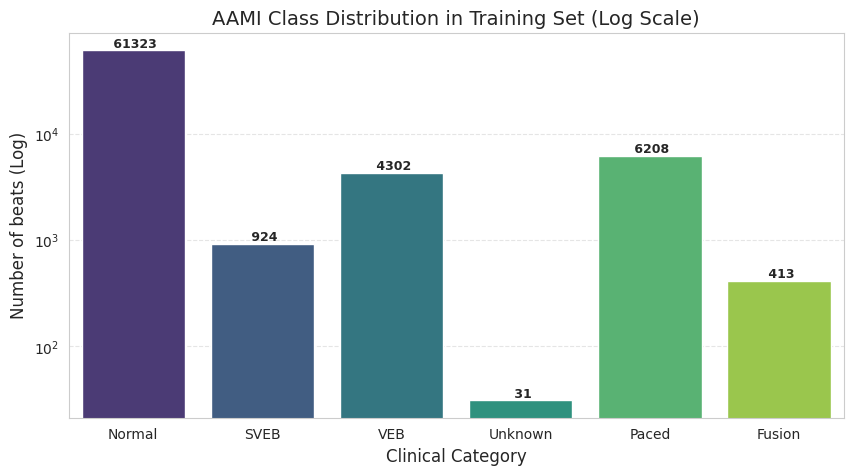

Summary statistics:
 - Normal  :  61323 beats (83.77%)
 - SVEB    :    924 beats ( 1.26%)
 - VEB     :   4302 beats ( 5.88%)
 - Unknown :     31 beats ( 0.04%)
 - Paced   :   6208 beats ( 8.48%)
 - Fusion  :    413 beats ( 0.56%)


In [26]:
import seaborn as sns

# Collect all AAMI labels from training records for EDA
all_syms = []
for r in TRAIN_RECORDS:
    ann = wfdb.rdann(os.path.join(DATA_DIR, r), 'atr')
    all_syms.extend(ann.symbol)

# Filter out 'Other' to focus on AAMI classes
aami_labels = [get_aami_category(s) for s in all_syms if get_aami_category(s) != 'Other']
counts = Counter(aami_labels)

# Prepare data for Seaborn
categories = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

# Using hue=x to avoid future deprecation warnings and improve aesthetics
ax = sns.barplot(x=categories, y=values, hue=categories, palette='viridis', legend=False)

plt.yscale('log')
plt.title('AAMI Class Distribution in Training Set (Log Scale)', fontsize=14)
plt.ylabel('Number of beats (Log)', fontsize=12)
plt.xlabel('Clinical Category', fontsize=12)

# Add absolute counts on top of bars for clarity
for i, v in enumerate(values):
    ax.text(i, v, f' {v}', ha='center', va='bottom', fontsize=9, weight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print("Summary statistics:")
for cls, count in counts.items():
    perc = (count / len(aami_labels)) * 100
    print(f" - {cls:8}: {count:6} beats ({perc:5.2f}%)")

### 1.5 Train / Validation / Test Split

**Critical methodological choice: split by full records, not individual beats.**

Splitting at the beat level would allow segments from the same patient to appear in both training and testing sets, causing *data leakage*. By splitting by entire records, we simulate a real-world scenario: the model is evaluated on patients it has never seen before.

| Split | Records | Percentage | Purpose |
|---|---|---|---|
| Train | first 33 | 70% | Model training |
| Validation | next 7 | 15% | Hyperparameter tuning |
| Test | last 8 | 15% | Final evaluation

In [27]:
n       = len(ALL_RECORDS)
n_train = int(0.70 * n)   # 33 records
n_val   = int(0.15 * n)   # 7 records
# remaining records go to test

TRAIN_RECORDS = ALL_RECORDS[:n_train]
VAL_RECORDS   = ALL_RECORDS[n_train : n_train + n_val]
TEST_RECORDS  = ALL_RECORDS[n_train + n_val:]

print(f'Train : {len(TRAIN_RECORDS)} records')
print(f'Val   : {len(VAL_RECORDS)}   records')
print(f'Test  : {len(TEST_RECORDS)}  records')
print(f'\nTrain records : {TRAIN_RECORDS}')
print(f'Val records   : {VAL_RECORDS}')
print(f'Test records  : {TEST_RECORDS}')

Train : 33 records
Val   : 7   records
Test  : 8  records

Train records : ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212']
Val records   : ['213', '214', '215', '217', '219', '220', '221']
Test records  : ['222', '223', '228', '230', '231', '232', '233', '234']


### 1.6 Quick Record Analysis

Let's visualize 10 seconds of raw signal from record 100. Annotations indicate the beat type according to the AAMI standard (e.g., 'N' for Normal, 'V' for VEB).

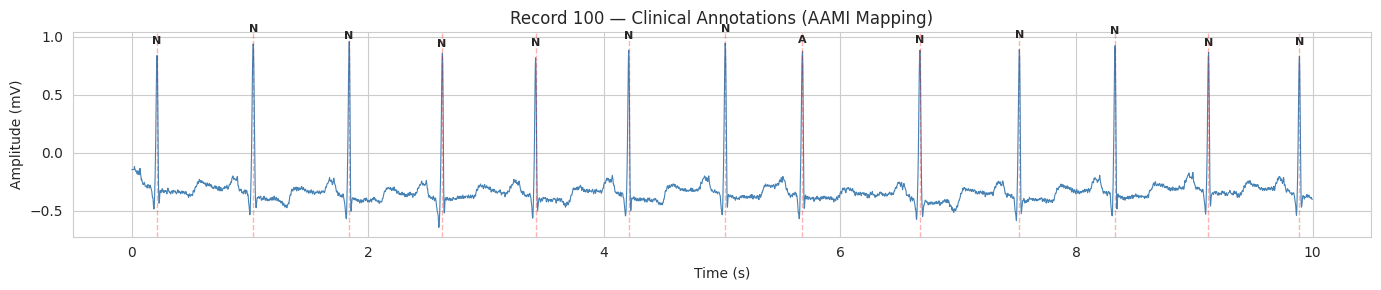

In [28]:
record     = wfdb.rdrecord(os.path.join(DATA_DIR, '100'))
annotation = wfdb.rdann(os.path.join(DATA_DIR, '100'), 'atr')

signal      = record.p_signal[:, 0]
ann_samples = annotation.sample
ann_symbols = np.array(annotation.symbol)

n_samples = 10 * FS
t         = np.arange(n_samples) / FS
mask      = ann_samples < n_samples

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t, signal[:n_samples], color='steelblue', lw=0.8, label='ECG signal')

for s, sym in zip(ann_samples[mask], ann_symbols[mask]):
    cat = get_aami_category(sym)
    if cat != 'Other':
        ax.axvline(s / FS, color='red', alpha=0.3, lw=1, linestyle='--')
        ax.text(s / FS, signal[s] + 0.1, sym, fontsize=8, weight='bold', ha='center')

ax.set(xlabel='Time (s)', ylabel='Amplitude (mV)',
       title='Record 100 — Clinical Annotations (AAMI Mapping)')
plt.tight_layout()
plt.show()